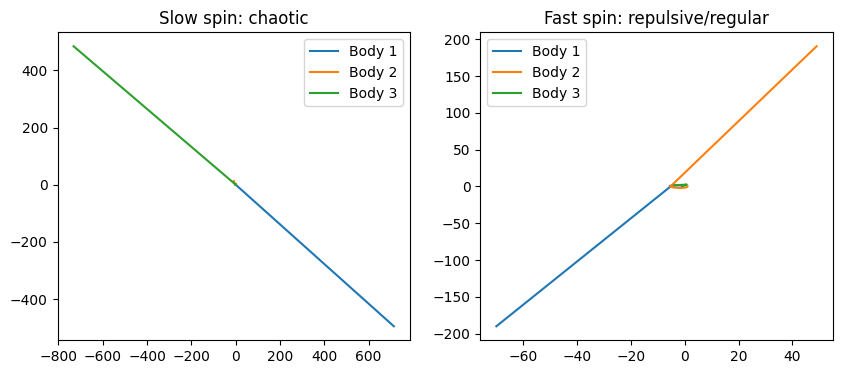

In [1]:
import numpy as np
import matplotlib.pyplot as plt

G = 1.0 # set G=1 for simplicity
k = 1.0 # start with k=1, we’ll tune later
dt = 0.01
steps = 5000

# 3 equal masses, hollow shells
m = np.array([1.0, 1.0, 1.0])
R = np.array([0.2, 0.2, 0.2])
I = 2/3 * m * R**2

# Initial positions: triangle
r = np.array([[-1.0, 0.0], [1.0, 0.0], [0.0, np.sqrt(3)]])
v = np.array([[0.0, 0.5], [0.0, -0.5], [-0.5, 0.0]]) # give them some motion

# Test 2 cases: slow spin vs fast spin
omega_slow = np.array([0.5, 0.5, 0.5]) # below crit
omega_fast = np.array([5.0, 5.0, 5.0]) # above crit

def simulate(omega):
    r_hist = [r.copy()]
    r_curr, v_curr = r.copy(), v.copy()
    for _ in range(steps):
        a = np.zeros((3,2))
        for j in range(3):
            for i in range(3):
                if i==j: continue
                rij = r_curr[j] - r_curr[i]
                dist = np.linalg.norm(rij)
                Geff = G - k * I[i] * omega[i]**2 / m[j]
                a[j] += -Geff * m[i] * rij / dist**3
        v_curr += a * dt
        r_curr += v_curr * dt
        r_hist.append(r_curr.copy())
    return np.array(r_hist)

# Run both
traj_slow = simulate(omega_slow)
traj_fast = simulate(omega_fast)

# Plot
fig, ax = plt.subplots(1,2, figsize=(10,4))
for i in range(3): ax[0].plot(traj_slow[:,i,0], traj_slow[:,i,1], label=f'Body {i+1}')
ax[0].set_title('Slow spin: chaotic'); ax[0].legend()

for i in range(3): ax[1].plot(traj_fast[:,i,0], traj_fast[:,i,1], label=f'Body {i+1}')
ax[1].set_title('Fast spin: repulsive/regular'); ax[1].legend()
plt.show()